In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split

x = np.load('/content/drive/MyDrive/alphabet/images_under.npy')
y = np.load('/content/drive/MyDrive/alphabet/encoded_labels_under.npy')

# لو الصور رمادية، نضيف قناة واحدة
if len(x.shape) == 3:
    x = np.expand_dims(x, axis=-1)

x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

input_shape = x.shape[1:]
num_classes = len(np.unique(y))


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_cnn():
    model = Sequential([

        # --- Block 1 ---
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 2 ---
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 3 ---
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 4 ---
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 5 ---
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Dense Layers ---
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model



--- Run 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
402/402 - 49s - 121ms/step - accuracy: 0.5374 - loss: 1.6112 - val_accuracy: 0.0932 - val_loss: 3.6835
Epoch 2/20
402/402 - 55s - 137ms/step - accuracy: 0.9211 - loss: 0.2574 - val_accuracy: 0.9819 - val_loss: 0.0898
Epoch 3/20
402/402 - 21s - 52ms/step - accuracy: 0.9761 - loss: 0.0879 - val_accuracy: 0.9877 - val_loss: 0.0497
Epoch 4/20
402/402 - 16s - 40ms/step - accuracy: 0.9852 - loss: 0.0539 - val_accuracy: 0.9880 - val_loss: 0.0472
Epoch 5/20
402/402 - 20s - 50ms/step - accuracy: 0.9890 - loss: 0.0398 - val_accuracy: 0.9876 - val_loss: 0.0486
Epoch 6/20
402/402 - 20s - 51ms/step - accuracy: 0.9887 - loss: 0.0398 - val_accuracy: 0.9869 - val_loss: 0.0514
Epoch 7/20
402/402 - 21s - 51ms/step - accuracy: 0.9900 - loss: 0.0354 - val_accuracy: 0.9890 - val_loss: 0.0484
Epoch 8/20
402/402 - 16s - 39ms/step - accuracy: 0.9888 - loss: 0.0385 - val_accuracy: 0.9862 - val_loss: 0.0600
Epoch 9/20
402/402 - 17s - 43ms/step - accuracy: 0.9875 - loss: 0.0401 - val_accuracy: 0.9919 

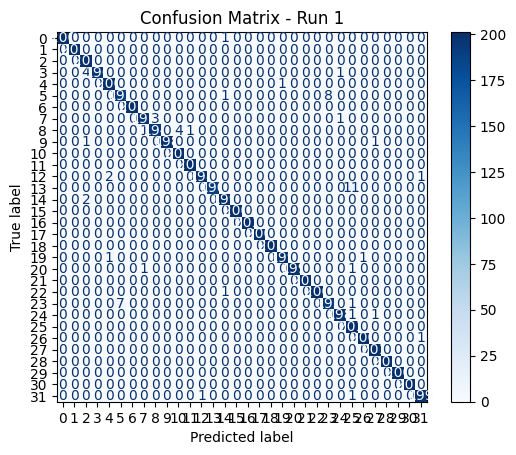

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MCC: 0.9900 | ROC AUC: 0.9998
F1 Weighted: 0.9904 | Precision Weighted: 0.9905 | Recall Weighted: 0.9904
Training Time: 443.77s | Memory Used: 1151.26 MB

--- Run 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
402/402 - 37s - 92ms/step - accuracy: 0.5181 - loss: 1.6860 - val_accuracy: 0.0664 - val_loss: 3.9655
Epoch 2/20
402/402 - 27s - 67ms/step - accuracy: 0.9092 - loss: 0.2922 - val_accuracy: 0.9763 - val_loss: 0.1002
Epoch 3/20
402/402 - 16s - 39ms/step - accuracy: 0.9724 - loss: 0.0968 - val_accuracy: 0.9830 - val_loss: 0.0679
Epoch 4/20
402/402 - 15s - 38ms/step - accuracy: 0.9851 - loss: 0.0555 - val_accuracy: 0.9841 - val_loss: 0.0535
Epoch 5/20
402/402 - 20s - 51ms/step - accuracy: 0.9877 - loss: 0.0451 - val_accuracy: 0.9882 - val_loss: 0.0459
Epoch 6/20
402/402 - 15s - 39ms/step - accuracy: 0.9883 - loss: 0.0397 - val_accuracy: 0.9877 - val_loss: 0.0492
Epoch 7/20
402/402 - 21s - 52ms/step - accuracy: 0.9901 - loss: 0.0342 - val_accuracy: 0.9877 - val_loss: 0.0502
Epoch 8/20
402/402 - 15s - 39ms/step - accuracy: 0.9886 - loss: 0.0381 - val_accuracy: 0.9890 - val_loss: 0.0457
Epoch 9/20
402/402 - 20s - 50ms/step - accuracy: 0.9873 - loss: 0.0430 - val_accuracy: 0.9844 - 

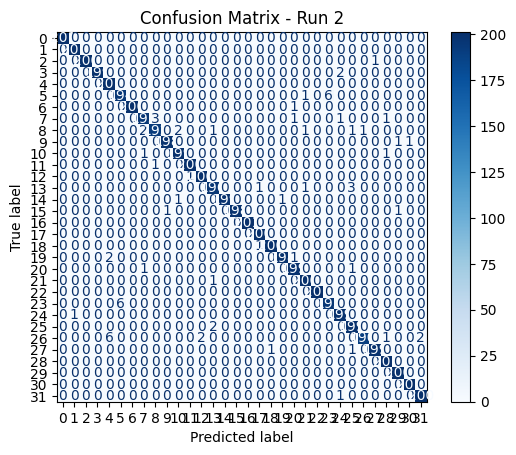

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MCC: 0.9888 | ROC AUC: 0.9999
F1 Weighted: 0.9891 | Precision Weighted: 0.9892 | Recall Weighted: 0.9891
Training Time: 404.33s | Memory Used: 281.80 MB

--- Run 3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
402/402 - 36s - 90ms/step - accuracy: 0.5312 - loss: 1.6407 - val_accuracy: 0.0745 - val_loss: 4.4578
Epoch 2/20
402/402 - 16s - 40ms/step - accuracy: 0.9213 - loss: 0.2606 - val_accuracy: 0.9787 - val_loss: 0.0958
Epoch 3/20
402/402 - 20s - 50ms/step - accuracy: 0.9732 - loss: 0.0944 - val_accuracy: 0.9821 - val_loss: 0.0673
Epoch 4/20
402/402 - 20s - 50ms/step - accuracy: 0.9819 - loss: 0.0626 - val_accuracy: 0.9874 - val_loss: 0.0487
Epoch 5/20
402/402 - 21s - 51ms/step - accuracy: 0.9904 - loss: 0.0369 - val_accuracy: 0.9885 - val_loss: 0.0424
Epoch 6/20
402/402 - 20s - 51ms/step - accuracy: 0.9895 - loss: 0.0364 - val_accuracy: 0.9866 - val_loss: 0.0544
Epoch 7/20
402/402 - 20s - 51ms/step - accuracy: 0.9866 - loss: 0.0438 - val_accuracy: 0.9882 - val_loss: 0.0459
Epoch 8/20
402/402 - 20s - 51ms/step - accuracy: 0.9886 - loss: 0.0405 - val_accuracy: 0.9866 - val_loss: 0.0538
Epoch 9/20
402/402 - 21s - 51ms/step - accuracy: 0.9926 - loss: 0.0260 - val_accuracy: 0.9840 - 

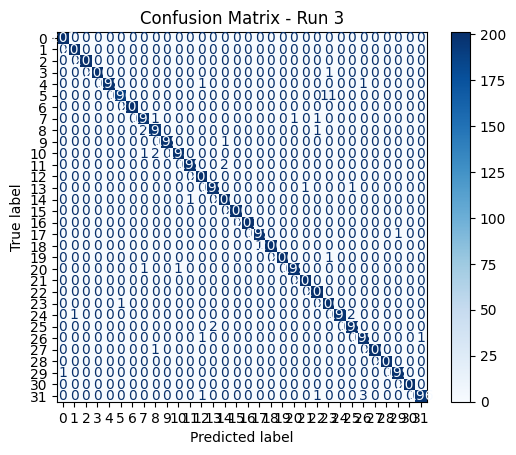

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
MCC: 0.9921 | ROC AUC: 1.0000
F1 Weighted: 0.9924 | Precision Weighted: 0.9925 | Recall Weighted: 0.9924
Training Time: 392.73s | Memory Used: 250.01 MB

--- Run 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
402/402 - 38s - 95ms/step - accuracy: 0.5210 - loss: 1.6641 - val_accuracy: 0.0352 - val_loss: 5.3995
Epoch 2/20
402/402 - 24s - 60ms/step - accuracy: 0.9113 - loss: 0.2927 - val_accuracy: 0.9759 - val_loss: 0.1021
Epoch 3/20
402/402 - 20s - 50ms/step - accuracy: 0.9724 - loss: 0.0973 - val_accuracy: 0.9860 - val_loss: 0.0529
Epoch 4/20
402/402 - 16s - 39ms/step - accuracy: 0.9852 - loss: 0.0551 - val_accuracy: 0.9846 - val_loss: 0.0533
Epoch 5/20
402/402 - 20s - 51ms/step - accuracy: 0.9888 - loss: 0.0425 - val_accuracy: 0.9837 - val_loss: 0.0565
Epoch 6/20
402/402 - 21s - 52ms/step - accuracy: 0.9887 - loss: 0.0384 - val_accuracy: 0.9880 - val_loss: 0.0496
Epoch 7/20
402/402 - 16s - 40ms/step - accuracy: 0.9869 - loss: 0.0437 - val_accuracy: 0.9872 - val_loss: 0.0489
Epoch 8/20
402/402 - 20s - 49ms/step - accuracy: 0.9893 - loss: 0.0379 - val_accuracy: 0.9759 - val_loss: 0.0838
Epoch 9/20
402/402 - 16s - 39ms/step - accuracy: 0.9920 - loss: 0.0284 - val_accuracy: 0.9913 - 

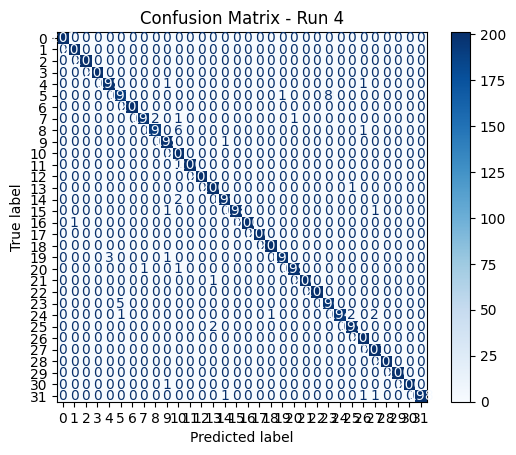

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MCC: 0.9913 | ROC AUC: 0.9999
F1 Weighted: 0.9916 | Precision Weighted: 0.9917 | Recall Weighted: 0.9916
Training Time: 406.65s | Memory Used: 217.34 MB

--- Run 5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
402/402 - 36s - 89ms/step - accuracy: 0.5495 - loss: 1.5772 - val_accuracy: 0.1917 - val_loss: 2.9387
Epoch 2/20
402/402 - 27s - 68ms/step - accuracy: 0.9255 - loss: 0.2448 - val_accuracy: 0.9795 - val_loss: 0.0859
Epoch 3/20
402/402 - 20s - 50ms/step - accuracy: 0.9769 - loss: 0.0855 - val_accuracy: 0.9879 - val_loss: 0.0502
Epoch 4/20
402/402 - 16s - 39ms/step - accuracy: 0.9860 - loss: 0.0524 - val_accuracy: 0.9830 - val_loss: 0.0651
Epoch 5/20
402/402 - 15s - 38ms/step - accuracy: 0.9892 - loss: 0.0390 - val_accuracy: 0.9871 - val_loss: 0.0467
Epoch 6/20
402/402 - 16s - 39ms/step - accuracy: 0.9903 - loss: 0.0337 - val_accuracy: 0.9809 - val_loss: 0.0632
Epoch 7/20
402/402 - 20s - 51ms/step - accuracy: 0.9863 - loss: 0.0486 - val_accuracy: 0.9866 - val_loss: 0.0517
Epoch 8/20
402/402 - 20s - 50ms/step - accuracy: 0.9885 - loss: 0.0395 - val_accuracy: 0.9888 - val_loss: 0.0397
Epoch 9/20
402/402 - 21s - 51ms/step - accuracy: 0.9912 - loss: 0.0291 - val_accuracy: 0.9872 - 

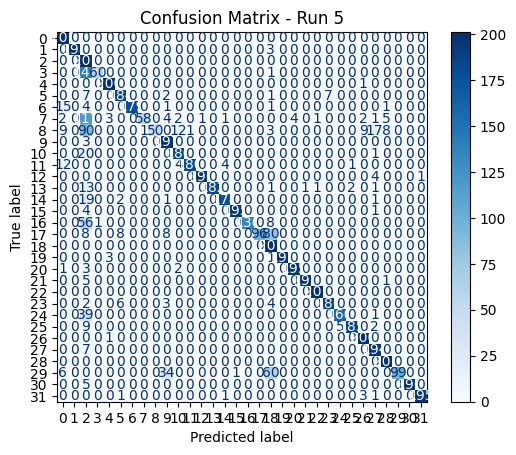

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MCC: 0.8519 | ROC AUC: 0.9975
F1 Weighted: 0.8554 | Precision Weighted: 0.9290 | Recall Weighted: 0.8522
Training Time: 402.52s | Memory Used: 182.64 MB

--- Run 6 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
402/402 - 36s - 90ms/step - accuracy: 0.5686 - loss: 1.5146 - val_accuracy: 0.1477 - val_loss: 3.2001
Epoch 2/20
402/402 - 17s - 42ms/step - accuracy: 0.9269 - loss: 0.2452 - val_accuracy: 0.9777 - val_loss: 0.0912
Epoch 3/20
402/402 - 16s - 39ms/step - accuracy: 0.9747 - loss: 0.0900 - val_accuracy: 0.9855 - val_loss: 0.0583
Epoch 4/20
402/402 - 20s - 50ms/step - accuracy: 0.9869 - loss: 0.0516 - val_accuracy: 0.9852 - val_loss: 0.0544
Epoch 5/20
402/402 - 21s - 52ms/step - accuracy: 0.9854 - loss: 0.0504 - val_accuracy: 0.9857 - val_loss: 0.0562
Epoch 6/20
402/402 - 21s - 52ms/step - accuracy: 0.9888 - loss: 0.0420 - val_accuracy: 0.9862 - val_loss: 0.0555
Epoch 7/20
402/402 - 16s - 40ms/step - accuracy: 0.9864 - loss: 0.0448 - val_accuracy: 0.9841 - val_loss: 0.0634
Epoch 8/20
402/402 - 19s - 48ms/step - accuracy: 0.9873 - loss: 0.0420 - val_accuracy: 0.9832 - val_loss: 0.0656
Epoch 9/20
402/402 - 21s - 51ms/step - accuracy: 0.9889 - loss: 0.0364 - val_accuracy: 0.9827 - 

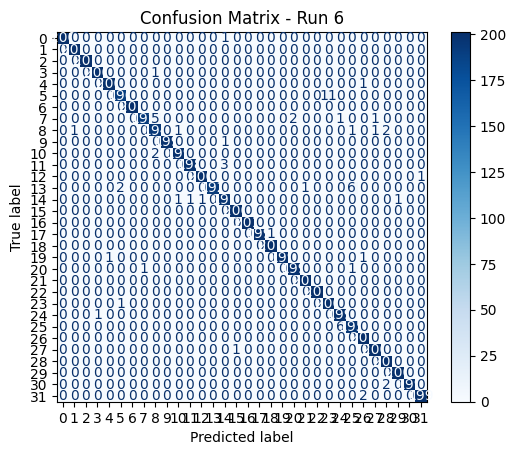

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MCC: 0.9892 | ROC AUC: 0.9999
F1 Weighted: 0.9896 | Precision Weighted: 0.9897 | Recall Weighted: 0.9896
Training Time: 398.80s | Memory Used: 183.31 MB

--- Run 7 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
402/402 - 39s - 97ms/step - accuracy: 0.5288 - loss: 1.6607 - val_accuracy: 0.1026 - val_loss: 4.0524
Epoch 2/20
402/402 - 16s - 40ms/step - accuracy: 0.9156 - loss: 0.2752 - val_accuracy: 0.9748 - val_loss: 0.1013
Epoch 3/20
402/402 - 20s - 50ms/step - accuracy: 0.9729 - loss: 0.0989 - val_accuracy: 0.9868 - val_loss: 0.0490
Epoch 4/20
402/402 - 16s - 39ms/step - accuracy: 0.9846 - loss: 0.0574 - val_accuracy: 0.9874 - val_loss: 0.0443
Epoch 5/20
402/402 - 16s - 39ms/step - accuracy: 0.9890 - loss: 0.0419 - val_accuracy: 0.9863 - val_loss: 0.0483
Epoch 6/20
402/402 - 20s - 51ms/step - accuracy: 0.9873 - loss: 0.0425 - val_accuracy: 0.9841 - val_loss: 0.0530
Epoch 7/20
402/402 - 21s - 51ms/step - accuracy: 0.9884 - loss: 0.0413 - val_accuracy: 0.9891 - val_loss: 0.0479
Epoch 8/20
402/402 - 15s - 38ms/step - accuracy: 0.9872 - loss: 0.0415 - val_accuracy: 0.9855 - val_loss: 0.0510
Epoch 9/20
402/402 - 15s - 38ms/step - accuracy: 0.9902 - loss: 0.0337 - val_accuracy: 0.9874 - 

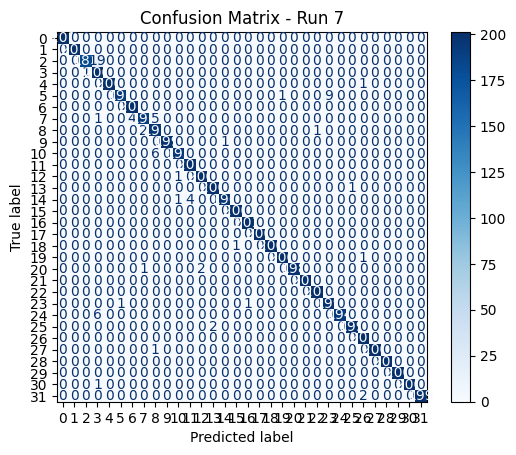

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MCC: 0.9876 | ROC AUC: 0.9999
F1 Weighted: 0.9881 | Precision Weighted: 0.9886 | Recall Weighted: 0.9880
Training Time: 388.84s | Memory Used: 245.11 MB

--- Run 8 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
402/402 - 36s - 90ms/step - accuracy: 0.5605 - loss: 1.5199 - val_accuracy: 0.0854 - val_loss: 3.3537
Epoch 2/20
402/402 - 16s - 39ms/step - accuracy: 0.9301 - loss: 0.2282 - val_accuracy: 0.9804 - val_loss: 0.0852
Epoch 3/20
402/402 - 16s - 39ms/step - accuracy: 0.9752 - loss: 0.0867 - val_accuracy: 0.9840 - val_loss: 0.0575
Epoch 4/20
402/402 - 15s - 39ms/step - accuracy: 0.9858 - loss: 0.0500 - val_accuracy: 0.9885 - val_loss: 0.0429
Epoch 5/20
402/402 - 21s - 51ms/step - accuracy: 0.9895 - loss: 0.0392 - val_accuracy: 0.9876 - val_loss: 0.0408
Epoch 6/20
402/402 - 21s - 52ms/step - accuracy: 0.9892 - loss: 0.0380 - val_accuracy: 0.9868 - val_loss: 0.0494
Epoch 7/20
402/402 - 20s - 50ms/step - accuracy: 0.9881 - loss: 0.0398 - val_accuracy: 0.9824 - val_loss: 0.0623
Epoch 8/20
402/402 - 20s - 50ms/step - accuracy: 0.9875 - loss: 0.0401 - val_accuracy: 0.9869 - val_loss: 0.0585
Epoch 9/20
402/402 - 20s - 50ms/step - accuracy: 0.9922 - loss: 0.0276 - val_accuracy: 0.9911 - 

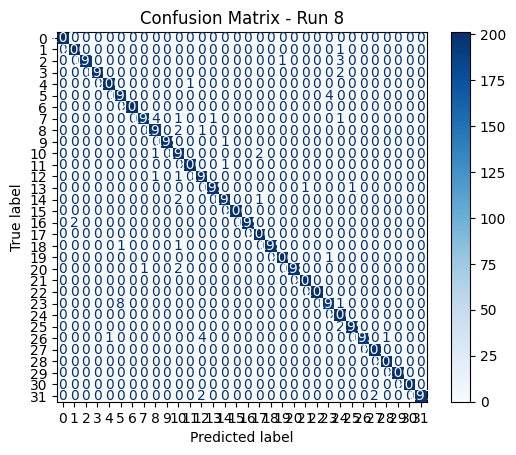

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MCC: 0.9899 | ROC AUC: 0.9999
F1 Weighted: 0.9902 | Precision Weighted: 0.9904 | Recall Weighted: 0.9902
Training Time: 397.21s | Memory Used: 154.22 MB

--- Run 9 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
402/402 - 37s - 92ms/step - accuracy: 0.5603 - loss: 1.5300 - val_accuracy: 0.1460 - val_loss: 3.3768
Epoch 2/20
402/402 - 16s - 39ms/step - accuracy: 0.9284 - loss: 0.2386 - val_accuracy: 0.9790 - val_loss: 0.0959
Epoch 3/20
402/402 - 16s - 39ms/step - accuracy: 0.9742 - loss: 0.0920 - val_accuracy: 0.9852 - val_loss: 0.0512
Epoch 4/20
402/402 - 15s - 38ms/step - accuracy: 0.9859 - loss: 0.0510 - val_accuracy: 0.9826 - val_loss: 0.0635
Epoch 5/20
402/402 - 20s - 51ms/step - accuracy: 0.9881 - loss: 0.0441 - val_accuracy: 0.9879 - val_loss: 0.0430
Epoch 6/20
402/402 - 16s - 39ms/step - accuracy: 0.9904 - loss: 0.0350 - val_accuracy: 0.9876 - val_loss: 0.0483
Epoch 7/20
402/402 - 20s - 51ms/step - accuracy: 0.9869 - loss: 0.0436 - val_accuracy: 0.9810 - val_loss: 0.0682
Epoch 8/20
402/402 - 20s - 50ms/step - accuracy: 0.9866 - loss: 0.0439 - val_accuracy: 0.9810 - val_loss: 0.0701
Epoch 9/20
402/402 - 21s - 52ms/step - accuracy: 0.9926 - loss: 0.0272 - val_accuracy: 0.9890 - 

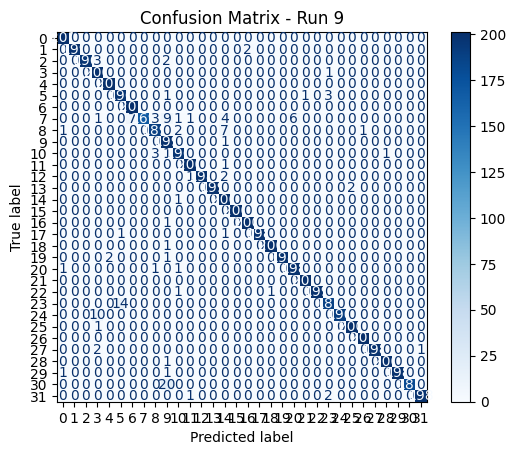

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MCC: 0.9784 | ROC AUC: 0.9999
F1 Weighted: 0.9790 | Precision Weighted: 0.9804 | Recall Weighted: 0.9790
Training Time: 376.47s | Memory Used: 185.77 MB

--- Run 10 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
402/402 - 36s - 89ms/step - accuracy: 0.5253 - loss: 1.6538 - val_accuracy: 0.0921 - val_loss: 3.6723
Epoch 2/20
402/402 - 27s - 66ms/step - accuracy: 0.9162 - loss: 0.2769 - val_accuracy: 0.9787 - val_loss: 0.0908
Epoch 3/20
402/402 - 16s - 39ms/step - accuracy: 0.9698 - loss: 0.1019 - val_accuracy: 0.9829 - val_loss: 0.0655
Epoch 4/20
402/402 - 20s - 51ms/step - accuracy: 0.9836 - loss: 0.0592 - val_accuracy: 0.9866 - val_loss: 0.0424
Epoch 5/20
402/402 - 20s - 50ms/step - accuracy: 0.9883 - loss: 0.0427 - val_accuracy: 0.9851 - val_loss: 0.0522
Epoch 6/20
402/402 - 21s - 53ms/step - accuracy: 0.9899 - loss: 0.0368 - val_accuracy: 0.9858 - val_loss: 0.0471
Epoch 7/20
402/402 - 20s - 50ms/step - accuracy: 0.9883 - loss: 0.0398 - val_accuracy: 0.9883 - val_loss: 0.0452
Epoch 8/20
402/402 - 20s - 50ms/step - accuracy: 0.9909 - loss: 0.0355 - val_accuracy: 0.9813 - val_loss: 0.0657
Epoch 9/20
402/402 - 15s - 38ms/step - accuracy: 0.9908 - loss: 0.0331 - val_accuracy: 0.9849 - 

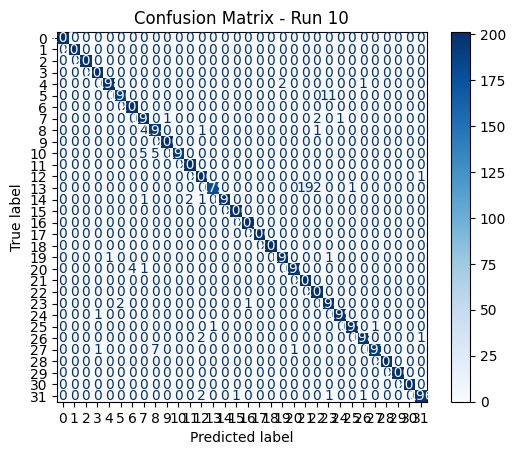

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MCC: 0.9854 | ROC AUC: 0.9999
F1 Weighted: 0.9858 | Precision Weighted: 0.9863 | Recall Weighted: 0.9858
Training Time: 390.84s | Memory Used: 239.42 MB
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.990352  0.046143  0.990046  0.999818     0.990363   
1    2      0.989107  0.045229  0.988759  0.999881     0.989089   
2    3      0.992375  0.032652  0.992133  0.999957     0.992383   
3    4      0.991597  0.033725  0.991329  0.999927     0.991604   
4    5      0.852163  0.925336  0.851945  0.997454     0.855370   
5    6      0.989574  0.043928  0.989242  0.999874     0.989567   
6    7      0.988017  0.046303  0.987648  0.999940     0.988068   
7    8      0.990196  0.046465  0.989884  0.999903     0.990218   
8    9      0.978992  0.081366  0.978359  0.999861     0.979032   
9   10      0.985839  0.055768  0.985399  0.999913     0.985821   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Use

In [4]:
import time
import psutil
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np

num_runs = 10
results = []

for run in range(1, num_runs+1):
    print(f"\n--- Run {run} ---")

    # --- Start measuring memory & time ---
    start_time = time.time()
    start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB

    model = build_cnn()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=20,
        batch_size=64,
        verbose=2
    )

    # --- End measuring memory & time ---
    end_time = time.time()
    end_mem = psutil.Process().memory_info().rss / (1024 ** 2)

    train_time = end_time - start_time
    train_memory = end_mem - start_mem

    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")

    # --- Predictions ---
    y_pred = np.argmax(model.predict(x_val), axis=1)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Run {run}")
    plt.show()

    # --- MCC ---
    mcc = matthews_corrcoef(y_val, y_pred)

    # --- ROC AUC ---
    y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))
    y_pred_prob = model.predict(x_val)
    roc_auc = roc_auc_score(y_val_bin, y_pred_prob, average='macro', multi_class='ovr')

    # --- Weighted metrics ---
    f1_w = f1_score(y_val, y_pred, average='weighted')
    precision_w = precision_score(y_val, y_pred, average='weighted')
    recall_w = recall_score(y_val, y_pred, average='weighted')

    print(f"MCC: {mcc:.4f} | ROC AUC: {roc_auc:.4f}")
    print(f"F1 Weighted: {f1_w:.4f} | Precision Weighted: {precision_w:.4f} | Recall Weighted: {recall_w:.4f}")
    print(f"Training Time: {train_time:.2f}s | Memory Used: {train_memory:.2f} MB")

    # --- Store all metrics ---
    results.append({
        'Run': run,
        'Val_Accuracy': val_acc,
        'Val_Loss': val_loss,
        'MCC': mcc,
        'ROC_AUC': roc_auc,
        'F1_Weighted': f1_w,
        'Precision_Weighted': precision_w,
        'Recall_Weighted': recall_w,
        'Training_Time(s)': train_time,
        'Memory_Used(MB)': train_memory
    })

# --- Convert to DataFrame & save ---
df_metrics = pd.DataFrame(results)
print(df_metrics)
df_metrics.to_excel("all_metrics_10runs_with_time_memory.xlsx", index=False)
print("Saved all metrics with time & memory for 10 runs to all_metrics_10runs_with_time_memory.xlsx")


In [5]:
df_results = pd.DataFrame(results)
df_results.to_excel('/content/drive/MyDrive/alphabet/CNN_runs_analysis_Under.xlsx', index=False)
print("✅ Results saved to CNN_runs_analysis.xlsx")
print(df_results)


✅ Results saved to CNN_runs_analysis.xlsx
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.990352  0.046143  0.990046  0.999818     0.990363   
1    2      0.989107  0.045229  0.988759  0.999881     0.989089   
2    3      0.992375  0.032652  0.992133  0.999957     0.992383   
3    4      0.991597  0.033725  0.991329  0.999927     0.991604   
4    5      0.852163  0.925336  0.851945  0.997454     0.855370   
5    6      0.989574  0.043928  0.989242  0.999874     0.989567   
6    7      0.988017  0.046303  0.987648  0.999940     0.988068   
7    8      0.990196  0.046465  0.989884  0.999903     0.990218   
8    9      0.978992  0.081366  0.978359  0.999861     0.979032   
9   10      0.985839  0.055768  0.985399  0.999913     0.985821   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.990550         0.990352        443.773410      1151.257812  
1            0.989171         0.989107        404.334795       281.8


📊 Average Results across all runs:
Average Accuracy : 0.9748
Average Loss     : 0.1357
Average MCC      : 0.9745
Average ROC AUC  : 0.9997

✅ Results saved to /content/drive/MyDrive/alphabet/CNN_runs_results_Under.xlsx


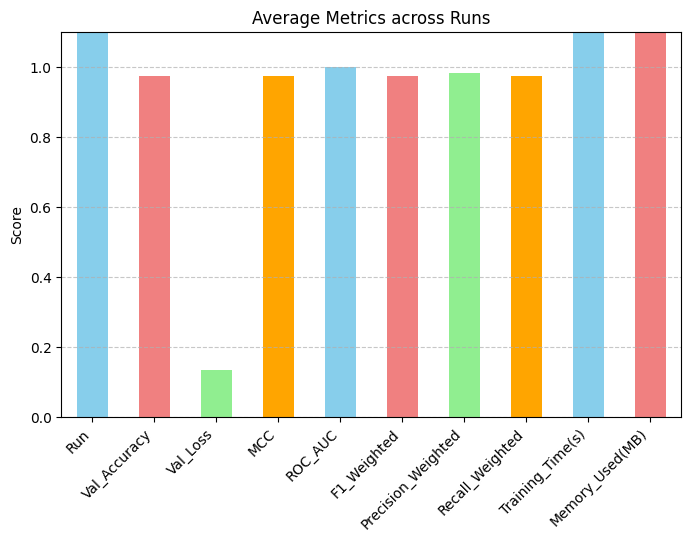

In [6]:
import matplotlib.pyplot as plt

# --- تحويل النتائج ل DataFrame ---
results_df = pd.DataFrame(results)

# --- حساب المتوسط لكل مقياس ---
avg_results = results_df.mean(numeric_only=True)

print("\n📊 Average Results across all runs:")
print(f"Average Accuracy : {avg_results['Val_Accuracy']:.4f}")
print(f"Average Loss     : {avg_results['Val_Loss']:.4f}")
print(f"Average MCC      : {avg_results['MCC']:.4f}")
print(f"Average ROC AUC  : {avg_results['ROC_AUC']:.4f}")

# --- حفظ النتائج في Excel ---
save_path = "/content/drive/MyDrive/alphabet/CNN_runs_results_Under.xlsx"
with pd.ExcelWriter(save_path) as writer:
    results_df.to_excel(writer, sheet_name="All Runs", index=False)
    avg_results.to_frame(name="Average").to_excel(writer, sheet_name="Average")

print(f"\n✅ Results saved to {save_path}")

# --- رسم المتوسطات ---
plt.figure(figsize=(8,5))
avg_results.plot(kind='bar', color=['skyblue','lightcoral','lightgreen','orange'])
plt.title("Average Metrics across Runs")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)  # معظم المقاييس بتبقى بين 0 و 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=78af41ac61d38a10a468873c163bd631e1e3b6626088e840b53809cca0cd3eb8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
📐 Input Shape: 64x64x1


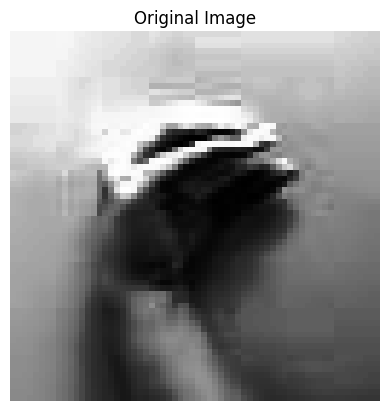

Predicted class: jeem (0.86)


  0%|          | 0/1000 [00:00<?, ?it/s]

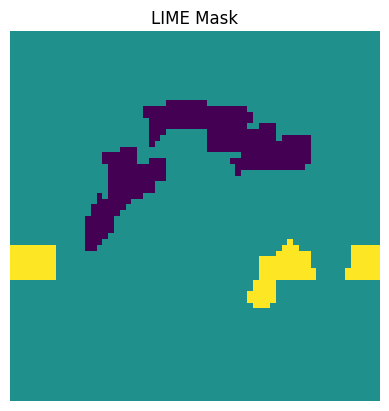

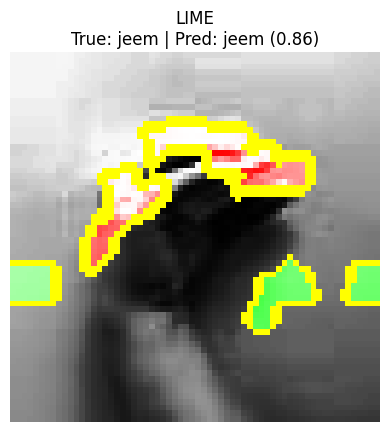

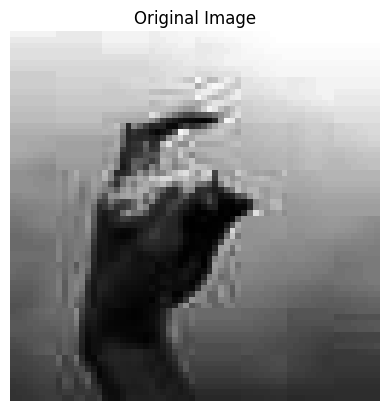

Predicted class: ra (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

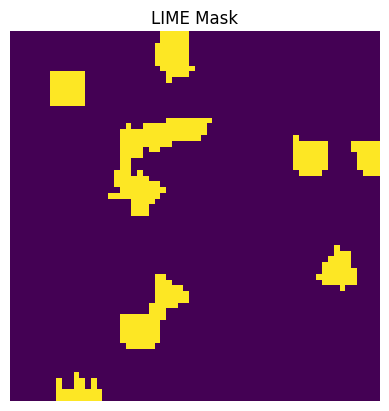

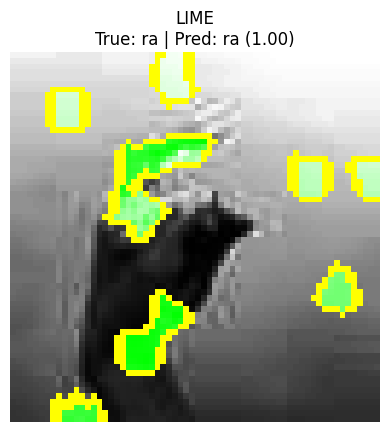

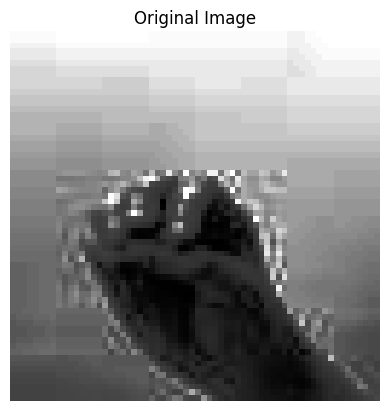

Predicted class: ha (0.53)


  0%|          | 0/1000 [00:00<?, ?it/s]

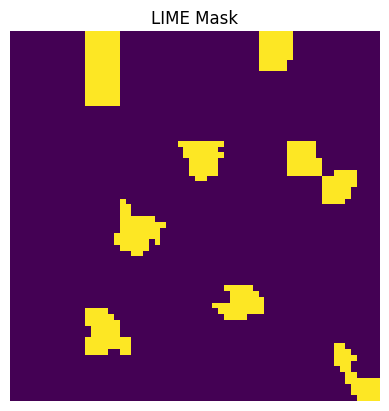

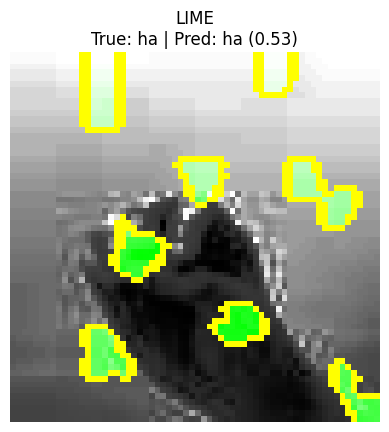

In [7]:
!pip install lime
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.transform import resize

# تحميل أسماء الكلاسات
class_names = np.load('/content/drive/MyDrive/alphabet/label_encoder_classes.npy', allow_pickle=True)

# استخراج شكل مدخلات الموديل
H, W, C = model.input_shape[1:]
print(f"📐 Input Shape: {H}x{W}x{C}")

# دالة تجهيز الصور زي التدريب
def preprocess_batch(images):
    out = []
    for im in images:
        im = np.asarray(im)
        if im.ndim == 2:  # صورة رمادية
            im = np.repeat(im[..., np.newaxis], 3, axis=-1)
            im = np.squeeze(im)
        elif im.shape[-1] == 1 and C == 3:
            im = np.repeat(im, 3, axis=-1)
            im = np.squeeze(im)
        # تغيير الحجم لتوافق مدخلات الموديل
        im = resize(im, (H, W, C), preserve_range=True, anti_aliasing=True).astype('float32')
        if im.max() > 1.0:
            im = im / 255.0
        out.append(im)
    return np.asarray(out, dtype='float32')

# دالة التنبؤ لـ LIME
def predict_fn(images):
    Xb = preprocess_batch(images)
    return model.predict(Xb, verbose=0)

# إنشاء مفسر LIME
explainer = lime_image.LimeImageExplainer()

# اختيار صور عشوائية للتفسير
indices = np.random.choice(len(x_val), size=3, replace=False)

for idx in indices:
    image = x_val[idx]

    # تجهيز نسخة RGB للعرض
    if image.ndim == 2 or image.shape[-1] == 1:
        image_rgb = np.repeat(image[..., np.newaxis], 3, axis=-1)
        image_rgb = np.squeeze(image_rgb)
    else:
        image_rgb = image
    image_rgb = image_rgb[..., :3]

    # --- عرض الصورة الأصلية ---
    plt.figure()
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # --- تنبؤ الموديل ---
    pred_probs = model.predict(preprocess_batch([image]), verbose=0)[0]
    pred_label = int(np.argmax(pred_probs))
    print(f"Predicted class: {class_names[pred_label]} ({pred_probs[pred_label]:.2f})")

    # --- تفسير LIME ---
    explanation = explainer.explain_instance(
        image_rgb.astype('double'),
        predict_fn,
        labels=[pred_label],
        hide_color=0,
        num_samples=1000,
        segmentation_fn=slic
    )

    # --- استخراج الـ mask ---
    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    # --- عرض الـ mask ---
    plt.figure()
    plt.imshow(mask)
    plt.title("LIME Mask")
    plt.axis('off')
    plt.show()

    # --- عرض الصورة مع الحدود ---
    true_class_name = class_names[int(y_val[idx])]
    predicted_class_name = class_names[pred_label]
    plt.figure()
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME\nTrue: {true_class_name} | Pred: {predicted_class_name} ({pred_probs[pred_label]:.2f})")
    plt.axis('off')
    plt.show()


In [8]:
import numpy as np

# حفظ الموديل بصيغة Keras الجديدة
model.save('/content/drive/MyDrive/alphabet/my_modelcnn_Under.keras')

# حفظ بيانات validation (لو محتاجة تكمل عليها)
np.save('/content/drive/MyDrive/alphabet/x_val_cnn_Under.npy', x_val)
np.save('/content/drive/MyDrive/alphabet/y_val_cnn_Under.npy', y_val)
